In [39]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as  sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_US = df[df['job_country']=='United States']

In [3]:
df_skills = df_US.explode('job_skills')

In [7]:
df_skills[['job_title','job_skills']].head(9)

,job_title,job_skills
0,Senior Clinical Data Engineer / Principal Clin...,NaN
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,python
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,c++
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,java
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,matlab
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,aws
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,tensorflow
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,keras
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,pytorch


In [34]:
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count',ascending=False , inplace=True)

df_skills_count.head(20)

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
1522,sql,Data Engineer,23958
1208,python,Data Engineer,22762
1611,tableau,Data Analyst,19311
1207,python,Data Analyst,18382
123,aws,Data Engineer,15018


In [22]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

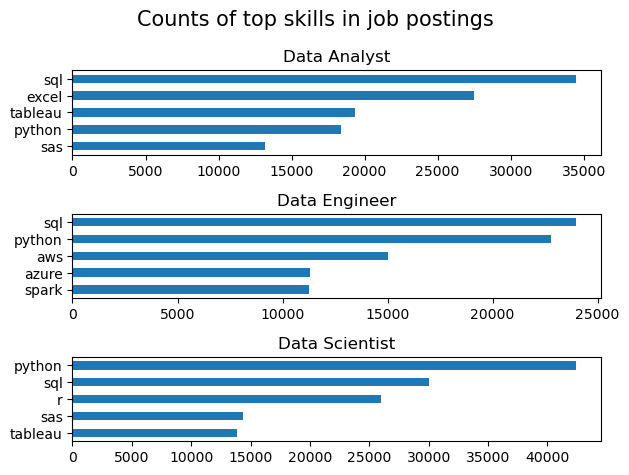

In [29]:
fig , ax = plt.subplots(len(job_titles),1)

for i,job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', title=job_title, ax=ax[i])
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Counts of top skills in job postings',fontsize=15)
fig.tight_layout()
plt.show()


    

In [32]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [37]:
df_skills_perc = pd.merge(df_skills_count,df_job_title_count,how = 'left',on='job_title_short')

df_skills_perc['skill_percent'] = 100 * df_skills_perc['skill_count']/df_skills_perc['jobs_total']

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


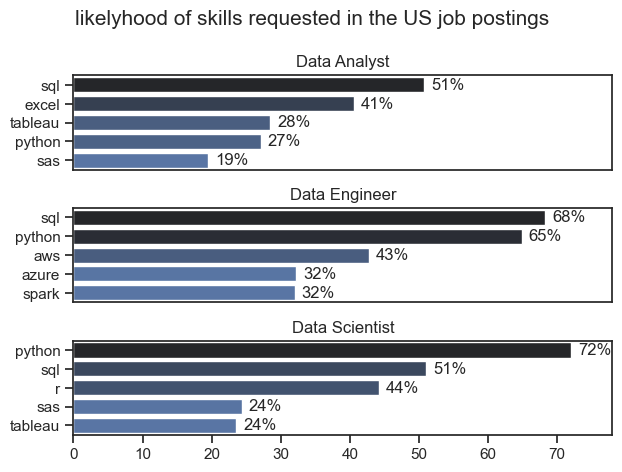

In [58]:
fig , ax = plt.subplots(len(job_titles),1)

sns.set_theme(style='ticks')

for i,job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short']==job_title].head(5)
    ##df_plot.plot(kind='barh', x='job_skills', y='skill_percent', title=job_title, ax=ax[i])
    sns.barplot(data=df_plot,x='skill_percent' , y='job_skills', ax=ax[i], hue='skill_count',palette='dark:b_r' )
    ax[i].set_title(job_title)
    ##ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,78)

    ##add percentages for each plot
    for n,v in enumerate(df_plot['skill_percent']):
        ax[i].text(v+1,n,f'{v:.0f}%',va='center')
    
    ## X axis for last plot only
    if i != len(job_titles)-1 :
        #print(i, len(job_titles)-1 )
        ax[i].set_xticks([])

fig.suptitle('likelyhood of skills requested in the US job postings',fontsize=15)
fig.tight_layout()
plt.show()